# Курсовая работа: Предсказание возраста моллюсков (XGBoost)

## Задача
Предсказать количество колец (Rings) моллюсков, что соответствует их возрасту.

## План работы
1. Загрузка и предобработка данных
2. Создание новых признаков (Feature Engineering)
3. Обучение модели XGBoost Regressor 
4. Оценка качества модели
5. Предсказание на тестовом датасете

## 1. Импорт библиотек

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

## 2. Загрузка данных

In [50]:
# Загрузка тренировочных данных
train_df = pd.read_csv('data/train.csv')
print(f"Размер тренировочного датасета: {train_df.shape}")
print("\nПервые строки:")
train_df.head()

Размер тренировочного датасета: (90615, 10)

Первые строки:


,id,Sex,Length,Diameter,Height,Whole weight,Whole weight.1,Whole weight.2,Shell weight,Rings
0,0,F,0.550,0.430,0.150,0.7715,0.3285,0.1465,0.2400,11
1,1,F,0.630,0.490,0.145,1.1300,0.4580,0.2765,0.3200,11
2,2,I,0.160,0.110,0.025,0.0210,0.0055,0.0030,0.0050,6
3,3,M,0.595,0.475,0.150,0.9145,0.3755,0.2055,0.2500,10
4,4,I,0.555,0.425,0.130,0.7820,0.3695,0.1600,0.1975,9


In [51]:
# Загрузка тестовых данных
test_df = pd.read_csv('data/test.csv')
print(f"Размер тестового датасета: {test_df.shape}")
print("\nПервые строки:")
test_df.head()

Размер тестового датасета: (60411, 9)

Первые строки:


,id,Sex,Length,Diameter,Height,Whole weight,Whole weight.1,Whole weight.2,Shell weight
0,90615,M,0.645,0.475,0.155,1.2380,0.6185,0.3125,0.3005
1,90616,M,0.580,0.460,0.160,0.9830,0.4785,0.2195,0.2750
2,90617,M,0.560,0.420,0.140,0.8395,0.3525,0.1845,0.2405
3,90618,M,0.570,0.490,0.145,0.8740,0.3525,0.1865,0.2350
4,90619,I,0.415,0.325,0.110,0.3580,0.1575,0.0670,0.1050


In [52]:
# Информация о данных
print("Информация о тренировочных данных:")
train_df.info()

print("\n" + "="*70)
print("Статистика:")
train_df.describe()

Информация о тренировочных данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90615 entries, 0 to 90614
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              90615 non-null  int64  
 1   Sex             90615 non-null  object 
 2   Length          90615 non-null  float64
 3   Diameter        90615 non-null  float64
 4   Height          90615 non-null  float64
 5   Whole weight    90615 non-null  float64
 6   Whole weight.1  90615 non-null  float64
 7   Whole weight.2  90615 non-null  float64
 8   Shell weight    90615 non-null  float64
 9   Rings           90615 non-null  int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 6.9+ MB

Статистика:


,id,Length,Diameter,Height,Whole weight,Whole weight.1,Whole weight.2,Shell weight,Rings
count,90615.000000,90615.000000,90615.000000,90615.000000,90615.000000,90615.000000,90615.000000,90615.000000,90615.000000
mean,45307.000000,0.517098,0.401679,0.135464,0.789035,0.340778,0.169422,0.225898,9.696794
std,26158.441658,0.118217,0.098026,0.038008,0.457671,0.204428,0.100909,0.130203,3.176221
min,0.000000,0.075000,0.055000,0.000000,0.002000,0.001000,0.000500,0.001500,1.000000
25%,22653.500000,0.445000,0.345000,0.110000,0.419000,0.177500,0.086500,0.120000,8.000000
50%,45307.000000,0.545000,0.425000,0.140000,0.799500,0.330000,0.166000,0.225000,9.000000
75%,67960.500000,0.600000,0.470000,0.160000,1.067500,0.463000,0.232500,0.305000,11.000000
max,90614.000000,0.815000,0.650000,1.130000,2.825500,1.488000,0.760000,1.005000,29.000000


## 3. Предобработка данных

На основе EDA анализа выполним:
1. Создание новых признаков (Volume, Surface Area, Ratios)
2. Обработка мультиколлинеарности
3. **One-Hot Encoding для Sex**

In [53]:
def preprocess_data(df, is_train=True):
    """     
    Parameters:
    -----------
    df : pandas.DataFrame
        Исходный датасет
    is_train : bool
        Флаг, указывающий является ли это тренировочным датасетом
    
    Returns:
    --------
    pandas.DataFrame
        Предобработанный датасет
    """
    df_processed = df.copy()
    
    # 1. Создание новых признаков    
    # Объемные метрики
    df_processed['Volume'] = (df_processed['Length'] * 
                               df_processed['Diameter'] * 
                               df_processed['Height'])
    
    df_processed['Surface_Area'] = 2 * (
        df_processed['Length'] * df_processed['Diameter'] + 
        df_processed['Length'] * df_processed['Height'] + 
        df_processed['Diameter'] * df_processed['Height']
    )
    
    # Соотношения размеров
    df_processed['Length_to_Diameter'] = df_processed['Length'] / (df_processed['Diameter'] + 1e-6)
    df_processed['Height_to_Length'] = df_processed['Height'] / (df_processed['Length'] + 1e-6)
    df_processed['Height_to_Diameter'] = df_processed['Height'] / (df_processed['Diameter'] + 1e-6)
    
    # Весовые соотношения
    df_processed['Meat_ratio'] = df_processed['Whole weight.1'] / (df_processed['Whole weight'] + 1e-6)
    df_processed['Viscera_ratio'] = df_processed['Whole weight.2'] / (df_processed['Whole weight'] + 1e-6)
    df_processed['Shell_ratio'] = df_processed['Shell weight'] / (df_processed['Whole weight'] + 1e-6)
    
    # Плотность
    df_processed['Density'] = df_processed['Whole weight'] / (df_processed['Volume'] + 1e-6)
    
    # Общий вес без раковины
    df_processed['Meat_total'] = (df_processed['Whole weight.1'] + 
                                   df_processed['Whole weight.2'])
        
    # 2. One-Hot кодирование категориального признака Sex
    sex_dummies = pd.get_dummies(df_processed['Sex'], prefix='Sex', drop_first=False)
    df_processed = pd.concat([df_processed, sex_dummies], axis=1)
    df_processed.drop('Sex', axis=1, inplace=True)
    
    # 3. Обработка мультиколлинеарности    
    # На основе EDA: Length и Diameter почти идентичны (r=0.9897)
    # Whole weight, Whole weight.1, Whole weight.2 сильно коррелируют
    
    features_to_drop = [
        'Length',          # Оставляем Diameter (более коррелирует с целевой)
        'Whole weight.1',  # Уже учтено в Meat_ratio и Meat_total
        'Whole weight.2',  # Уже учтено в Viscera_ratio и Meat_total
    ]
    
    df_processed.drop(features_to_drop, axis=1, inplace=True)
    
    # 4. Удаление id 
    if 'id' in df_processed.columns:
        df_processed.drop('id', axis=1, inplace=True)
    
    print(f"\n{'='*70}")
    print(f"Итоговый размер: {df_processed.shape}")
    print(f"{'='*70}\n")
    
    return df_processed

# Применяем предобработку
train_processed = preprocess_data(train_df, is_train=True)
test_processed = preprocess_data(test_df, is_train=False)


Итоговый размер: (90615, 18)


Итоговый размер: (60411, 17)



In [54]:
# Просмотр обработанных данных
print("Обработанные признаки:")
print(train_processed.columns.tolist())
print(f"\nВсего признаков: {train_processed.shape[1]}")

print("\nПервые строки обработанных данных:")
train_processed.head()

Обработанные признаки:
['Diameter', 'Height', 'Whole weight', 'Shell weight', 'Rings', 'Volume', 'Surface_Area', 'Length_to_Diameter', 'Height_to_Length', 'Height_to_Diameter', 'Meat_ratio', 'Viscera_ratio', 'Shell_ratio', 'Density', 'Meat_total', 'Sex_F', 'Sex_I', 'Sex_M']

Всего признаков: 18

Первые строки обработанных данных:


,Diameter,Height,Whole weight,Shell weight,Rings,Volume,Surface_Area,Length_to_Diameter,Height_to_Length,Height_to_Diameter,Meat_ratio,Viscera_ratio,Shell_ratio,Density,Meat_total,Sex_F,Sex_I,Sex_M
0,0.430,0.150,0.7715,0.2400,11,0.035475,0.76700,1.279067,0.272727,0.348836,0.425793,0.189890,0.311082,21.747097,0.4750,True,False,False
1,0.490,0.145,1.1300,0.3200,11,0.044761,0.94220,1.285712,0.230158,0.295918,0.405309,0.244690,0.283186,25.244345,0.7345,True,False,False
2,0.110,0.025,0.0210,0.0050,6,0.000440,0.04870,1.454532,0.156249,0.227271,0.261892,0.142850,0.238084,47.619048,0.0085,False,True,False
3,0.475,0.150,0.9145,0.2500,10,0.042394,0.88625,1.252629,0.252100,0.315789,0.410606,0.224713,0.273373,21.571067,0.5810,False,False,True
4,0.425,0.130,0.7820,0.1975,9,0.030664,0.72655,1.305879,0.234234,0.305882,0.472506,0.204603,0.252557,25.501594,0.5295,False,True,False


## 4. Разделение данных на признаки и целевую переменную

In [55]:
# Разделение на X и y
X = train_processed.drop('Rings', axis=1)
y = train_processed['Rings']

print(f"Размер X: {X.shape}")
print(f"Размер y: {y.shape}")
print(f"\nПризнаки для обучения ({X.shape[1]}):")
print(X.columns.tolist())

Размер X: (90615, 17)
Размер y: (90615,)

Признаки для обучения (17):
['Diameter', 'Height', 'Whole weight', 'Shell weight', 'Volume', 'Surface_Area', 'Length_to_Diameter', 'Height_to_Length', 'Height_to_Diameter', 'Meat_ratio', 'Viscera_ratio', 'Shell_ratio', 'Density', 'Meat_total', 'Sex_F', 'Sex_I', 'Sex_M']


In [56]:
# Разделение на train и validation
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## 5. Обучение модели XGBoost Regressor

In [57]:
# Обучение модели 
xgboost_model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.01,
    max_depth=6,
    min_child_weight=7,
    subsample=0.7,
    colsample_bytree=0.7,
    gamma=0.5,
    reg_alpha=0.1,
    reg_lambda=1.5,
    random_state=42,
    n_jobs=-1,
    verbosity=1,
    eval_metric='rmse',
    early_stopping_rounds=50  
  )

xgboost_model.fit(
  X_train, y_train,
  eval_set=[(X_train, y_train), (X_val, y_val)],
  verbose=100  
  )

[0]	validation_0-rmse:3.15021	validation_1-rmse:3.18664
[100]	validation_0-rmse:2.10764	validation_1-rmse:2.16237
[200]	validation_0-rmse:1.87362	validation_1-rmse:1.94104
[300]	validation_0-rmse:1.81525	validation_1-rmse:1.89275
[400]	validation_0-rmse:1.79192	validation_1-rmse:1.87929
[499]	validation_0-rmse:1.77721	validation_1-rmse:1.87435


,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.7
,device,None
,early_stopping_rounds,50
,enable_categorical,False
,eval_metric,'rmse'


## 6. Оценка качества модели

In [58]:
# Предсказания на тренировочной выборке
y_train_pred = xgboost_model.predict(X_train)

# Предсказания на валидационной выборке
y_val_pred = xgboost_model.predict(X_val)

In [59]:
def calculate_rmsle(y_true, y_pred):
    """
    Расчет Root Mean Squared Logarithmic Error (RMSLE)
    
    RMSLE = sqrt(mean((log(y_pred + 1) - log(y_true + 1))^2))
    """
    y_pred = np.maximum(y_pred, 0)
    
    log_pred = np.log1p(y_pred)  # log(1 + y_pred)
    log_true = np.log1p(y_true)  # log(1 + y_true)
    
    squared_log_error = (log_pred - log_true) ** 2
    rmsle = np.sqrt(np.mean(squared_log_error))
    
    return rmsle

def evaluate_model(y_true, y_pred, dataset_name=""):
    """
    Расчет всех метрик качества
    """
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    rmsle = calculate_rmsle(y_true, y_pred)
    
    print(f"\nМетрики на {dataset_name}:")
    print("="*70)
    print(f"RMSE (Root Mean Squared Error):              {rmse:.4f}")
    print(f"MAE (Mean Absolute Error):                   {mae:.4f}")
    print(f"R² Score:                                    {r2:.4f}")
    print(f"RMSLE (Root Mean Squared Logarithmic Error): {rmsle:.4f}")
    print("="*70)
    
    return {
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2,
        'RMSLE': rmsle
    }

# Оценка на тренировочной выборке
train_metrics = evaluate_model(y_train, y_train_pred, "тренировочной выборке")

# Оценка на валидационной выборке
val_metrics = evaluate_model(y_val, y_val_pred, "валидационной выборке")


Метрики на тренировочной выборке:
RMSE (Root Mean Squared Error):              1.7772
MAE (Mean Absolute Error):                   1.2083
R² Score:                                    0.6855
RMSLE (Root Mean Squared Logarithmic Error): 0.1456

Метрики на валидационной выборке:
RMSE (Root Mean Squared Error):              1.8744
MAE (Mean Absolute Error):                   1.2656
R² Score:                                    0.6580
RMSLE (Root Mean Squared Logarithmic Error): 0.1526


In [60]:
# Сравнение метрик
metrics_df = pd.DataFrame([train_metrics, val_metrics], index=['Train', 'Validation']).T
metrics_df['Difference'] = metrics_df['Train'] - metrics_df['Validation']

print("\nСравнение метрик:")
print(metrics_df)

# Проверка на переобучение
overfitting_ratio = val_metrics['RMSE'] / train_metrics['RMSE']
print(f"\nКоэффициент переобучения (Validation RMSE / Train RMSE): {overfitting_ratio:.3f}")
if overfitting_ratio < 1.2:
    print("Переобучение минимальное")
elif overfitting_ratio < 1.5:
    print("Умеренное переобучение")
else:
    print("Сильное переобучение")


Сравнение метрик:
          Train  Validation  Difference
RMSE   1.777209    1.874353   -0.097144
MAE    1.208250    1.265576   -0.057326
R2     0.685482    0.657995    0.027487
RMSLE  0.145575    0.152611   -0.007036

Коэффициент переобучения (Validation RMSE / Train RMSE): 1.055
Переобучение минимальное


## 7. Важность признаков


Топ-15 наиболее важных признаков:
           Feature  Importance
      Shell weight    0.285339
            Height    0.240692
        Meat_ratio    0.106128
            Volume    0.087575
      Whole weight    0.069873
       Shell_ratio    0.047679
             Sex_I    0.039269
      Surface_Area    0.026814
  Height_to_Length    0.018277
        Meat_total    0.016446
          Diameter    0.012920
     Viscera_ratio    0.010583
Height_to_Diameter    0.009620
           Density    0.008145
             Sex_F    0.007408


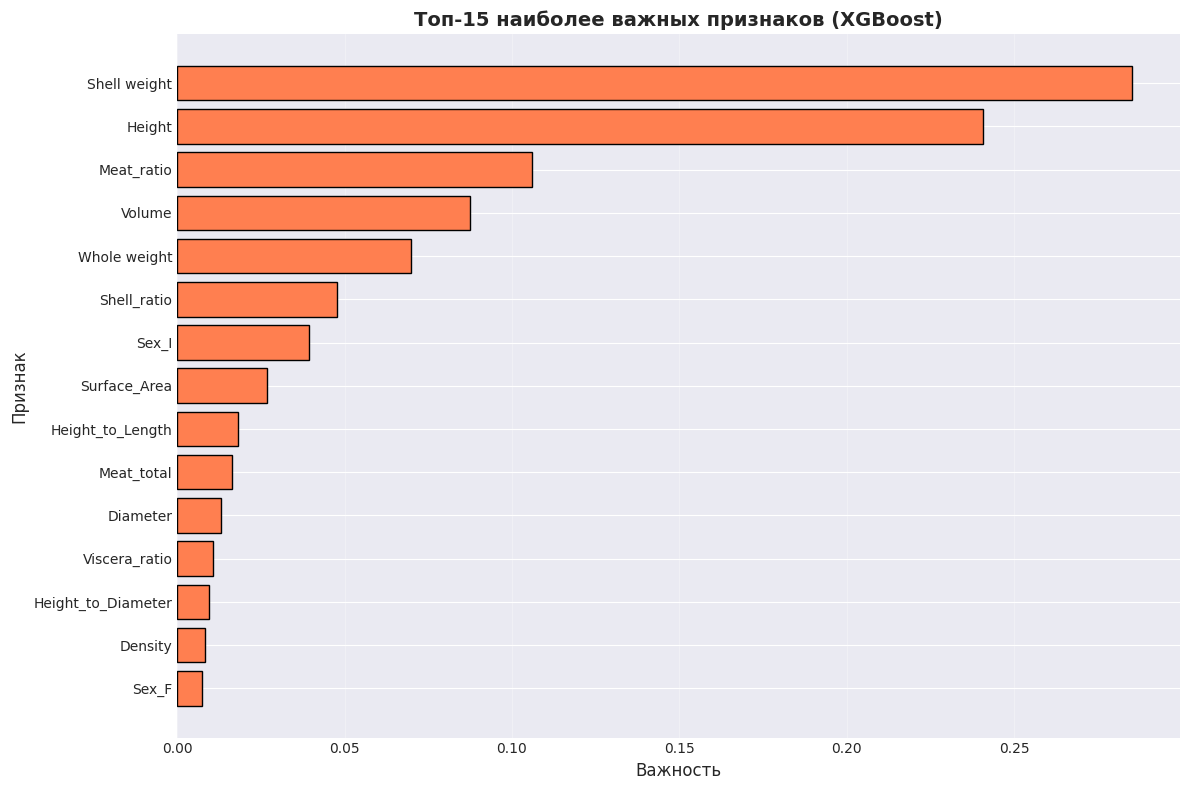

In [61]:
# Извлечение важности признаков
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgboost_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nТоп-15 наиболее важных признаков:")
print("="*70)
print(feature_importance.head(15).to_string(index=False))

# Визуализация важности признаков
plt.figure(figsize=(12, 8))
top_features = feature_importance.head(15)
plt.barh(top_features['Feature'], top_features['Importance'], color='coral', edgecolor='black')
plt.xlabel('Важность', fontsize=12)
plt.ylabel('Признак', fontsize=12)
plt.title('Топ-15 наиболее важных признаков (XGBoost)', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

## 8. Визуализация результатов

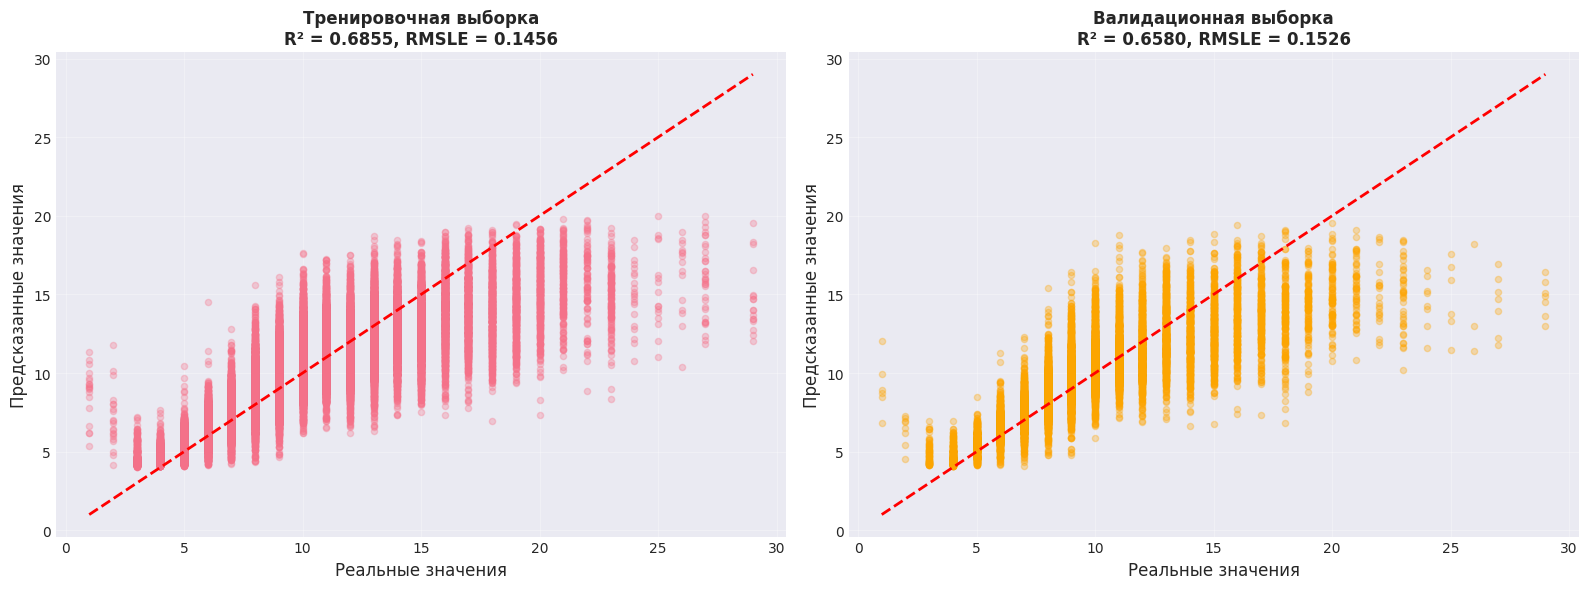

In [62]:
# График предсказаний и реальных значений
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Тренировочная выборка
axes[0].scatter(y_train, y_train_pred, alpha=0.3, s=20)
axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
axes[0].set_xlabel('Реальные значения', fontsize=12)
axes[0].set_ylabel('Предсказанные значения', fontsize=12)
axes[0].set_title(f'Тренировочная выборка\nR² = {train_metrics["R2"]:.4f}, RMSLE = {train_metrics["RMSLE"]:.4f}', 
                 fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Валидационная выборка
axes[1].scatter(y_val, y_val_pred, alpha=0.3, s=20, color='orange')
axes[1].plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', lw=2)
axes[1].set_xlabel('Реальные значения', fontsize=12)
axes[1].set_ylabel('Предсказанные значения', fontsize=12)
axes[1].set_title(f'Валидационная выборка\nR² = {val_metrics["R2"]:.4f}, RMSLE = {val_metrics["RMSLE"]:.4f}', 
                 fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

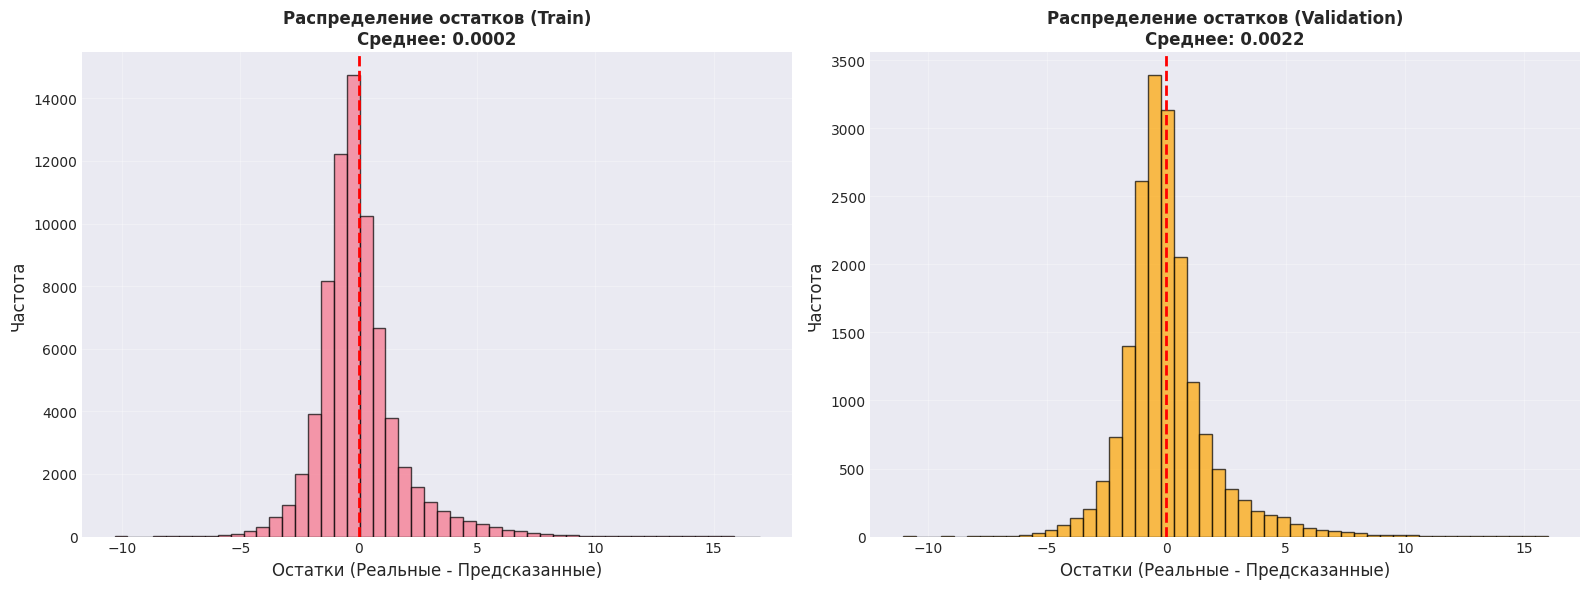

In [63]:
# Распределение ошибок
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Остатки (residuals)
train_residuals = y_train - y_train_pred
val_residuals = y_val - y_val_pred

# Гистограмма остатков тренировочная
axes[0].hist(train_residuals, bins=50, edgecolor='black', alpha=0.7)
axes[0].axvline(x=0, color='r', linestyle='--', linewidth=2)
axes[0].set_xlabel('Остатки (Реальные - Предсказанные)', fontsize=12)
axes[0].set_ylabel('Частота', fontsize=12)
axes[0].set_title(f'Распределение остатков (Train)\nСреднее: {train_residuals.mean():.4f}', 
                 fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Гистограмма остатков валидационная
axes[1].hist(val_residuals, bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[1].axvline(x=0, color='r', linestyle='--', linewidth=2)
axes[1].set_xlabel('Остатки (Реальные - Предсказанные)', fontsize=12)
axes[1].set_ylabel('Частота', fontsize=12)
axes[1].set_title(f'Распределение остатков (Validation)\nСреднее: {val_residuals.mean():.4f}', 
                 fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Предсказание на тестовом датасете

In [64]:
# Подготовка тестовых данных
X_test = test_processed.copy()

# Убедимся, что у нас те же признаки, что и при обучении
print("Проверка соответствия признаков:")
print(f"Признаков в train: {len(X_train.columns)}")
print(f"Признаков в test: {len(X_test.columns)}")

# Проверка на отсутствующие признаки
missing_features = set(X_train.columns) - set(X_test.columns)
extra_features = set(X_test.columns) - set(X_train.columns)

if missing_features:
    print(f"\n Отсутствующие признаки в test: {missing_features}")
    for feature in missing_features:
        X_test[feature] = 0

if extra_features:
    print(f"\ nЛишние признаки в test: {extra_features}")
    X_test = X_test.drop(columns=list(extra_features))

# Упорядочим признаки так же, как в тренировочной выборке
X_test = X_test[X_train.columns]

print("\nПризнаки согласованы")
print(f"Размер X_test: {X_test.shape}")

Проверка соответствия признаков:
Признаков в train: 17
Признаков в test: 17

Признаки согласованы
Размер X_test: (60411, 17)



Статистика предсказаний:
Минимум: 4.03
Максимум: 19.56
Среднее: 9.70
Медиана: 9.55


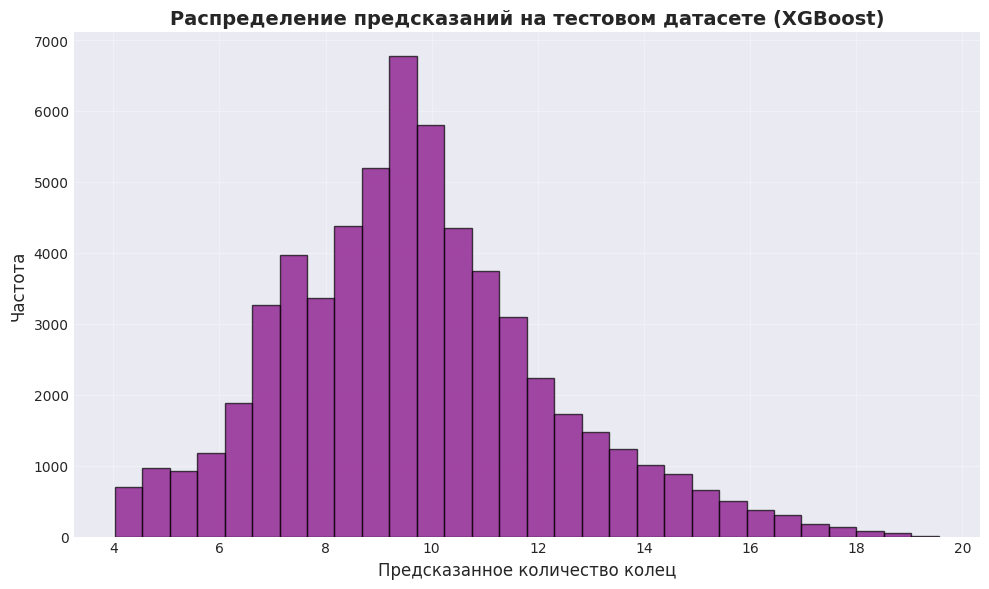

In [65]:
# Предсказание на тестовом датасете
y_test_pred = xgboost_model.predict(X_test)

y_test_pred = np.maximum(y_test_pred, 0)

print("\nСтатистика предсказаний:")
print(f"Минимум: {y_test_pred.min():.2f}")
print(f"Максимум: {y_test_pred.max():.2f}")
print(f"Среднее: {y_test_pred.mean():.2f}")
print(f"Медиана: {np.median(y_test_pred):.2f}")

# Визуализация распределения предсказаний
plt.figure(figsize=(10, 6))
plt.hist(y_test_pred, bins=30, edgecolor='black', alpha=0.7, color='purple')
plt.xlabel('Предсказанное количество колец', fontsize=12)
plt.ylabel('Частота', fontsize=12)
plt.title('Распределение предсказаний на тестовом датасете (XGBoost)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [66]:
# Создание файла с предсказаниями
submission = pd.DataFrame({
    'id': test_df['id'],
    'Rings': y_test_pred
})

submission.to_csv('submission_xgboost.csv', index=False)

## 10. Итоговый отчет

In [67]:
print("="*70)
print("ИТОГОВЫЙ ОТЧЕТ - XGBOOST")
print("="*70)

print("\n1. МОДЕЛЬ:")
print("   XGBoost Regressor")
print(f"   - n_estimators: {xgboost_model.n_estimators}")
print(f"   - learning_rate: {xgboost_model.learning_rate}")
print(f"   - max_depth: {xgboost_model.max_depth}")
print(f"   - subsample: {xgboost_model.subsample}")
print(f"   - colsample_bytree: {xgboost_model.colsample_bytree}")
print(f"   - reg_alpha (L1): {xgboost_model.reg_alpha}")
print(f"   - reg_lambda (L2): {xgboost_model.reg_lambda}")
print(f"   - Лучшая итерация: {xgboost_model.best_iteration}")

print("\n2. ДАННЫЕ:")
print(f"   - Тренировочная выборка: {X_train.shape[0]} записей")
print(f"   - Валидационная выборка: {X_val.shape[0]} записей")
print(f"   - Тестовая выборка: {X_test.shape[0]} записей")
print(f"   - Количество признаков: {X_train.shape[1]}")
print(f"   - Категориальные признаки закодированы: One-Hot Encoding")

print("\n3. МЕТРИКИ КАЧЕСТВА (ВАЛИДАЦИЯ):")
print(f"   - RMSE: {val_metrics['RMSE']:.4f}")
print(f"   - MAE: {val_metrics['MAE']:.4f}")
print(f"   - R² Score: {val_metrics['R2']:.4f}")
print(f"   - RMSLE: {val_metrics['RMSLE']:.4f}")

print("\n4. ТОП-5 ВАЖНЫХ ПРИЗНАКОВ:")
for idx, row in feature_importance.head(5).iterrows():
    print(f"   {row['Feature']}: {row['Importance']:.4f}")

print("\n5. ПРЕДСКАЗАНИЯ НА ТЕСТЕ:")
print(f"   - Среднее значение: {y_test_pred.mean():.2f} колец")
print(f"   - Диапазон: {y_test_pred.min():.2f} - {y_test_pred.max():.2f}")
print(f"   - Файл: submission_xgboost.csv")

ИТОГОВЫЙ ОТЧЕТ - XGBOOST

1. МОДЕЛЬ:
   XGBoost Regressor
   - n_estimators: 500
   - learning_rate: 0.01
   - max_depth: 6
   - subsample: 0.7
   - colsample_bytree: 0.7
   - reg_alpha (L1): 0.1
   - reg_lambda (L2): 1.5
   - Лучшая итерация: 499

2. ДАННЫЕ:
   - Тренировочная выборка: 72492 записей
   - Валидационная выборка: 18123 записей
   - Тестовая выборка: 60411 записей
   - Количество признаков: 17
   - Категориальные признаки закодированы: One-Hot Encoding

3. МЕТРИКИ КАЧЕСТВА (ВАЛИДАЦИЯ):
   - RMSE: 1.8744
   - MAE: 1.2656
   - R² Score: 0.6580
   - RMSLE: 0.1526

4. ТОП-5 ВАЖНЫХ ПРИЗНАКОВ:
   Shell weight: 0.2853
   Height: 0.2407
   Meat_ratio: 0.1061
   Volume: 0.0876
   Whole weight: 0.0699

5. ПРЕДСКАЗАНИЯ НА ТЕСТЕ:
   - Среднее значение: 9.70 колец
   - Диапазон: 4.03 - 19.56
   - Файл: submission_xgboost.csv
